In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

### Step 1: Load your image, convert to grey scale, crop and display it using matplotlib

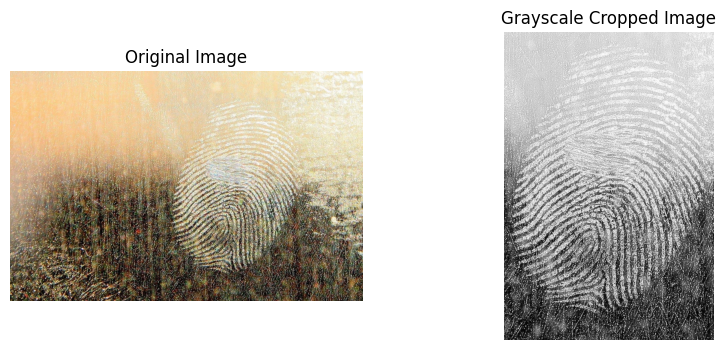

In [ ]:

# 1. Load image
img = cv2.imread("glass.png")

# check image loaded correctly
if img is None:
    print("Error: image not found")
    exit()

# 2. Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Crop region of interest
# adjust these values based on where the fingerprint is located
# format: gray[y1:y2, x1:x2]

cropped = gray[80:800, 570:1060]

# 4. Display images
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Grayscale Cropped Image")
plt.imshow(cropped, cmap="gray")
plt.axis("off")

plt.show()

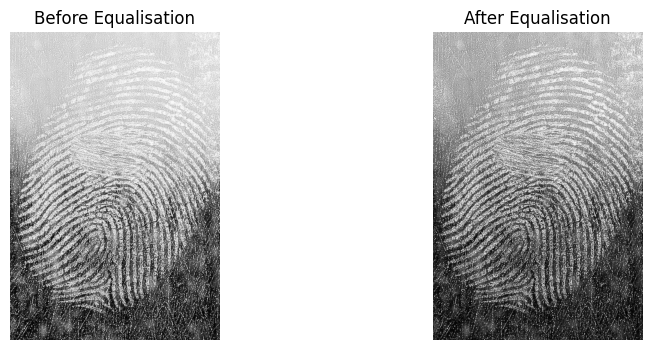

In [ ]:
# Step 2: Histogram Equalisation

equalised = cv2.equalizeHist(cropped)

# display comparison
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Before Equalisation")
plt.imshow(cropped, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After Equalisation")
plt.imshow(equalised, cmap="gray")
plt.axis("off")

plt.show()

Strided convolution

In [ ]:


def my_conv(image, kernel, stride=1):

    # image dimensions
    img_h, img_w = image.shape
    
    # kernel dimensions
    k_h, k_w = kernel.shape
    
    # output dimensions (no padding)
    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1
    
    # create empty output
    output = np.zeros((out_h, out_w))
    
    # perform convolution
    for i in range(out_h):
        for j in range(out_w):
            
            # define region of image
            region = image[
                i*stride : i*stride + k_h,
                j*stride : j*stride + k_w
            ]
            
            # element-wise multiplication and sum
            output[i, j] = np.sum(region * kernel)
    
    return output

Sobel Filtering

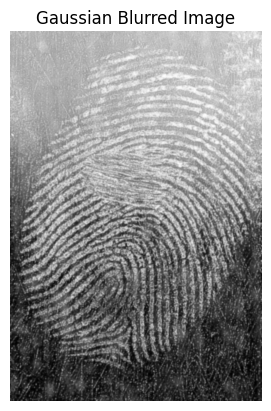

In [ ]:
blurred = cv2.GaussianBlur(equalised, (5,5), 1.0)

plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

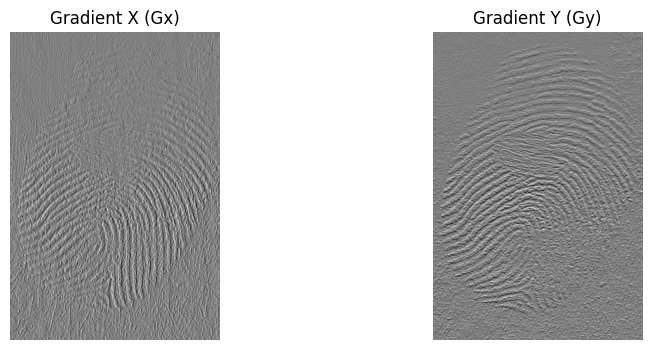

In [ ]:
Gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Gradient X (Gx)")
plt.imshow(Gx, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Gradient Y (Gy)")
plt.imshow(Gy, cmap="gray")
plt.axis("off")

plt.show()

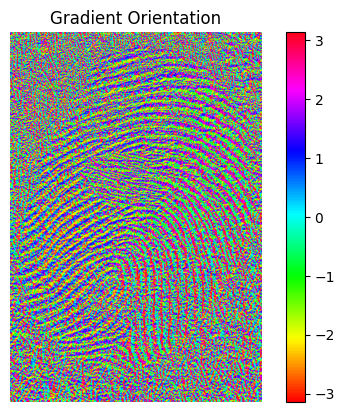

In [ ]:
orientation = np.arctan2(Gy, Gx)

plt.imshow(orientation, cmap="hsv")
plt.colorbar()
plt.title("Gradient Orientation")
plt.axis("off")
plt.show()

In [ ]:
blurred_1 = cv2.GaussianBlur(equalised, (3,3), 0.5)
blurred_2 = cv2.GaussianBlur(equalised, (7,7), 2.0)

Average Orientation and Histogram

In [ ]:
# d = 16

# H, W = Gx.shape

# orientation_blocks = np.zeros((H // d, W // d))

# for i in range(0, H - d, d):
#     for j in range(0, W - d, d):

#         block_Gx = Gx[i:i+d, j:j+d]
#         block_Gy = Gy[i:i+d, j:j+d]

#         sum_Gx = np.sum(block_Gx)
#         sum_Gy = np.sum(block_Gy)

#         orientation_blocks[i//d, j//d] = np.arctan2(sum_Gy, sum_Gx)

d = 16

# averaging kernel
kernel = np.ones((d, d)) / (d * d)

# use your convolution function with stride
avg_Gx = my_conv(Gx, kernel, stride=d)
avg_Gy = my_conv(Gy, kernel, stride=d)

# compute block orientations
orientation_blocks = np.arctan2(avg_Gy, avg_Gx)

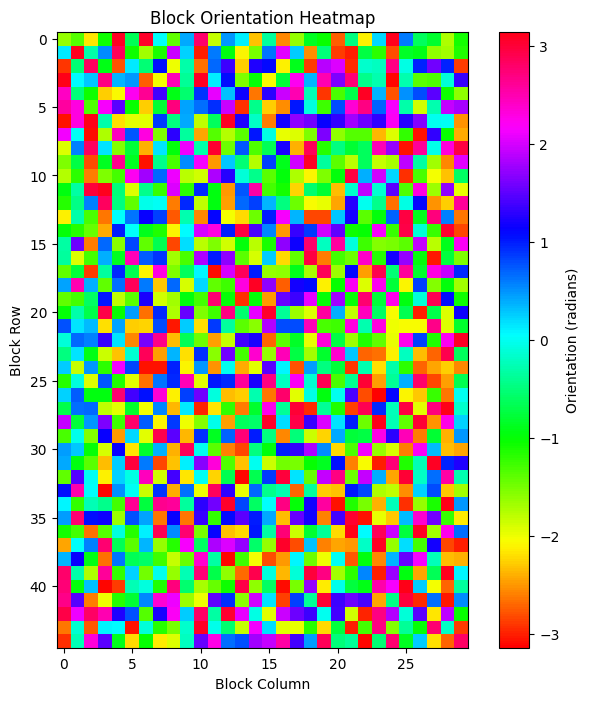

In [ ]:
#2D Heat Map similar to example provided in student pack

plt.figure(figsize=(8,8))

plt.imshow(
    orientation_blocks,
    cmap="hsv",
    origin="upper",
    vmin=-np.pi,
    vmax=np.pi
)

plt.colorbar(label="Orientation (radians)")
plt.title("Block Orientation Heatmap")
plt.xlabel("Block Column")
plt.ylabel("Block Row")
plt.show()

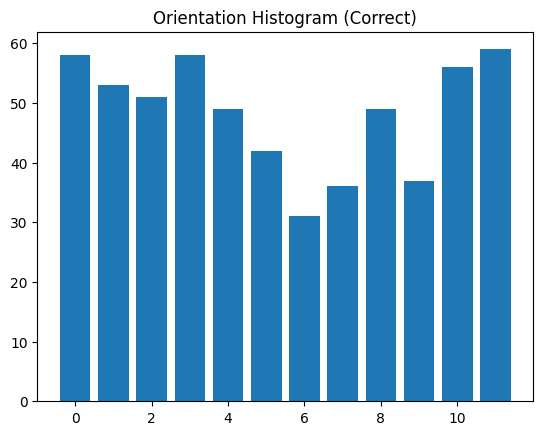

In [ ]:
k = 12

orient_values = orientation_blocks.flatten()

hist, bin_edges = np.histogram(
    orient_values,
    bins=k,
    range=(0, np.pi)
)

plt.bar(range(k), hist)
plt.title("Orientation Histogram (Correct)")
plt.show()

Gabor filters for each orientation bin above

In [ ]:
# Given to students.
def gabor(theta,ksize,sigma,freq):
    
    kern = cv2.getGaborKernel((ksize, ksize), sigma, theta, 10.0, freq, 0, ktype=cv2.CV_64F)
    kern /= 1.0 * kern.sum() 
    
    return kern

In [ ]:
k = 12
angles = np.linspace(0, np.pi, k, endpoint=False)
filters = []

for theta in angles:
    kernel = gabor(theta, ksize=21, sigma=4, freq=0.5)
    filters.append(kernel)

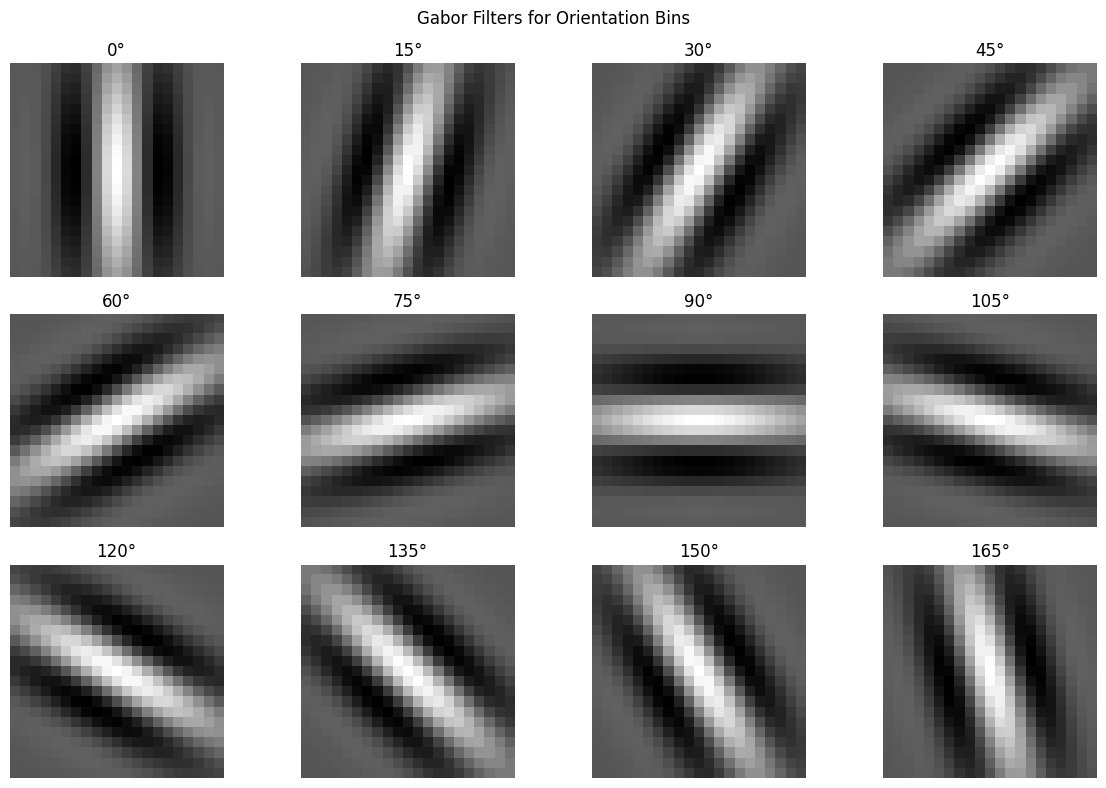

In [ ]:
plt.figure(figsize=(12, 8))

for i, kernel in enumerate(filters):
    plt.subplot(3, 4, i+1)
    plt.imshow(kernel, cmap="gray")
    plt.title(f"{np.degrees(angles[i]):.0f}°")
    plt.axis("off")

plt.suptitle("Gabor Filters for Orientation Bins")
plt.tight_layout()
plt.show()

In [ ]:
responses = []

for kernel in filters:
    response = cv2.filter2D(blurred, cv2.CV_64F, kernel)
    responses.append(response)

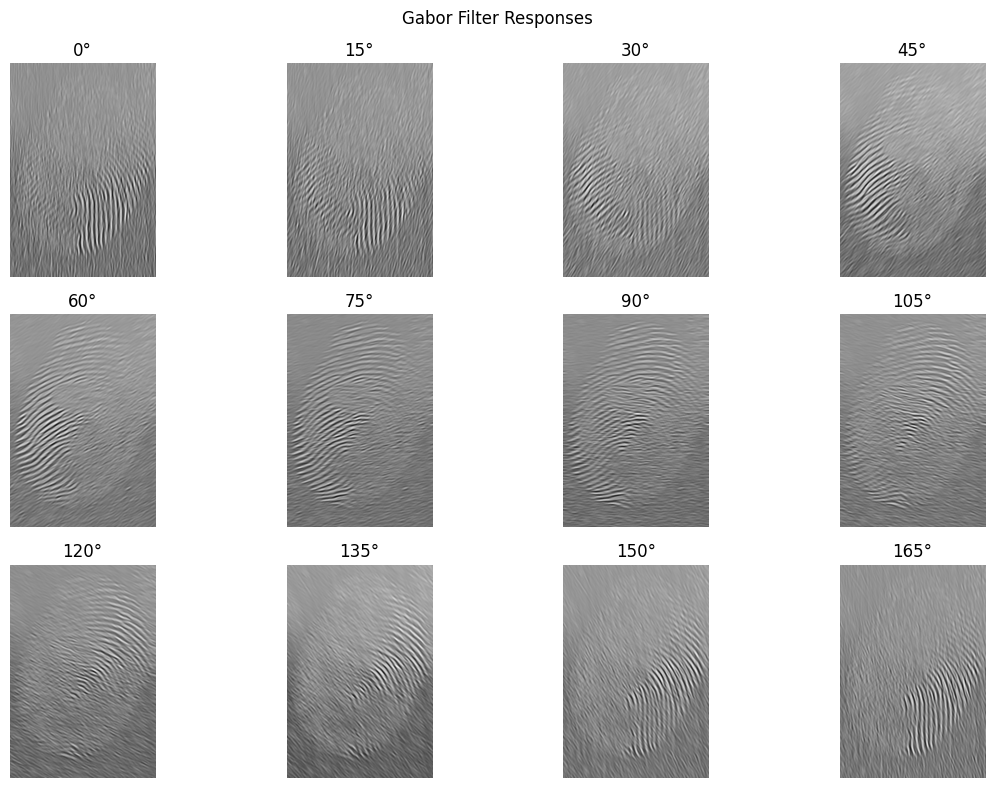

In [ ]:
plt.figure(figsize=(12, 8))

for i, response in enumerate(responses):
    plt.subplot(3, 4, i+1)
    plt.imshow(response, cmap="gray")
    plt.title(f"{np.degrees(angles[i]):.0f}°")
    plt.axis("off")

plt.suptitle("Gabor Filter Responses")
plt.tight_layout()
plt.show()

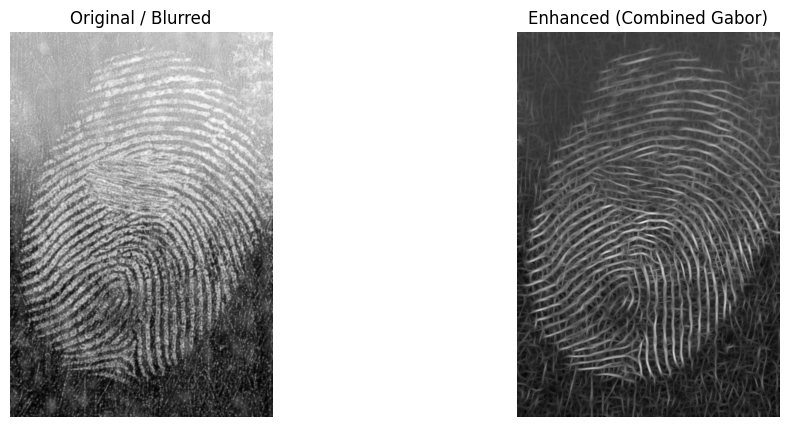

In [ ]:
combined_response = np.max(np.stack(responses), axis=0)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(blurred, cmap="gray")
plt.title("Original / Blurred")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(combined_response, cmap="gray")
plt.title("Enhanced (Combined Gabor)")
plt.axis("off")

plt.show()

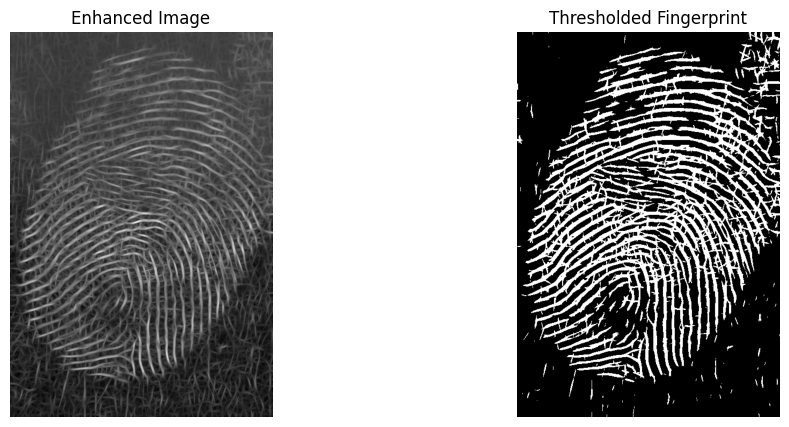

In [ ]:
enhanced_norm = cv2.normalize(
    combined_response,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

enhanced_norm = enhanced_norm.astype(np.uint8)

_, thresholded = cv2.threshold(
    enhanced_norm,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# --- CLEANING STEP (ADD HERE) ---
kernel = np.ones((3,3), np.uint8)

# remove noise
clean = cv2.morphologyEx(thresholded, cv2.MORPH_OPEN, kernel)

# close gaps in ridges
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(enhanced_norm, cmap="gray")
plt.title("Enhanced Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(thresholded, cmap="gray")
plt.title("Thresholded Fingerprint")
plt.axis("off")

plt.show()

In [ ]:
# convert to float32 (required by Harris)
thresh_float = np.float32(thresholded)

# Harris corner detection
corners = cv2.cornerHarris(
    thresh_float,
    blockSize=2,
    ksize=3,
    k=0.04
)

# dilate for better visibility
corners = cv2.dilate(corners, None)

In [ ]:
corner_mask = corners > 0.09 * corners.max()


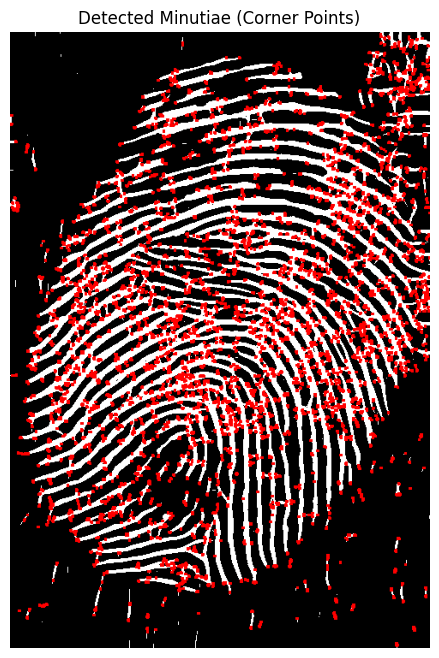

In [ ]:
minutiae_img = cv2.cvtColor(thresholded, cv2.COLOR_GRAY2RGB)

minutiae_img[corner_mask] = [255, 0, 0]   # red points

plt.figure(figsize=(8,8))
plt.imshow(minutiae_img)
plt.title("Detected Minutiae (Corner Points)")
plt.axis("off")
plt.show()

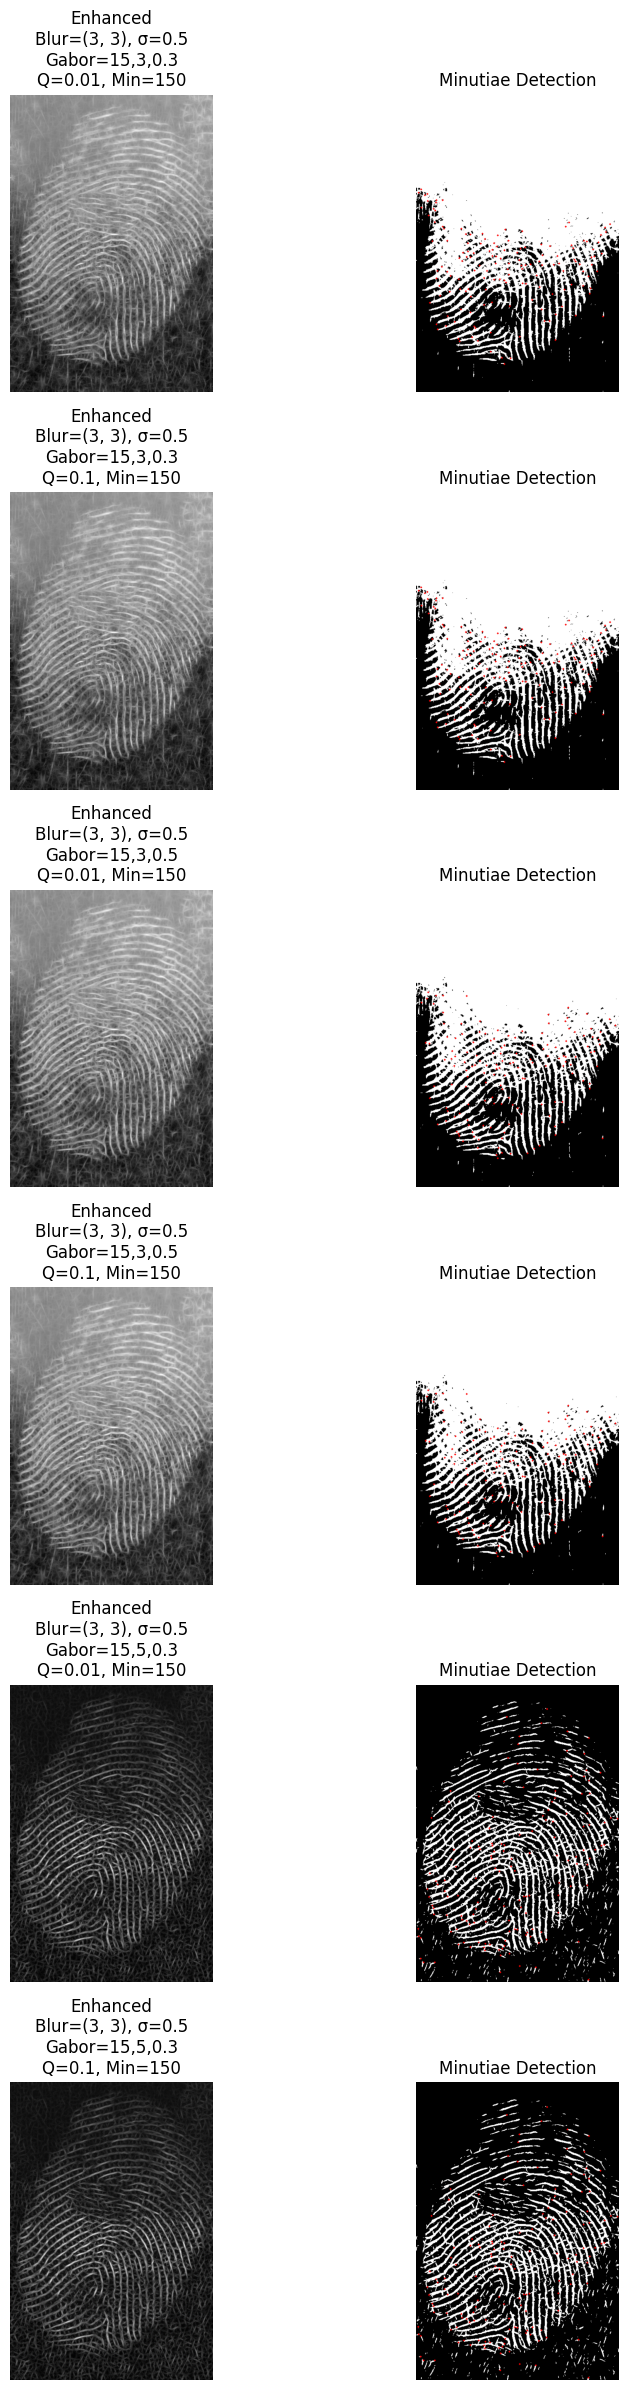

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from itertools import product

# =========================
# STEP 9: HYPERPARAMETER TUNING
# =========================

# ---- Parameter grid (6 parameters) ----
blur_kernels = [(3,3), (5,5)]
blur_sigmas = [0.5, 1.0]

gabor_ksizes = [15, 21]
gabor_sigmas = [3, 5]

gabor_freqs = [0.3, 0.5]

corner_quality = [0.01, 0.1]

# ---- Build all combinations ----
param_sets = list(product(
    blur_kernels,
    blur_sigmas,
    gabor_ksizes,
    gabor_sigmas,
    gabor_freqs,
    corner_quality
))

# only show first 6 best-looking comparisons to keep display readable
param_sets = param_sets[:6]

results = []

for idx, (blur_k, blur_s, gk, gs, gf, cq) in enumerate(param_sets):

    # -------------------------
    # 1. Gaussian blur
    # -------------------------
    blurred = cv2.GaussianBlur(equalised, blur_k, blur_s)

    # -------------------------
    # 2. Create Gabor filter bank
    # -------------------------
    angles = np.linspace(0, np.pi, 8, endpoint=False)

    responses = []

    for theta in angles:
        kernel = gabor(theta, gk, gs, gf)
        response = cv2.filter2D(blurred, cv2.CV_64F, kernel)
        responses.append(response)

    # -------------------------
    # 3. Combine responses
    # -------------------------
    enhanced = np.max(np.stack(responses), axis=0)

    enhanced_norm = cv2.normalize(
        enhanced,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # -------------------------
    # 4. Threshold
    # -------------------------
    _, thresh = cv2.threshold(
        enhanced_norm,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # -------------------------
    # 5. Minutiae detection
    # -------------------------
    corners = cv2.goodFeaturesToTrack(
        thresh,
        maxCorners=150,
        qualityLevel=cq,
        minDistance=5
    )

    minutiae_img = cv2.cvtColor(thresh, cv2.COLOR_GRAY2RGB)

    count = 0
    if corners is not None:
        corners = np.int32(corners)

        for corner in corners:
            x, y = corner.ravel()
            cv2.circle(minutiae_img, (x, y), 2, (255, 0, 0), -1)
            count += 1

    results.append((
        enhanced_norm,
        minutiae_img,
        f"Blur={blur_k}, σ={blur_s}\n"
        f"Gabor={gk},{gs},{gf}\n"
        f"Q={cq}, Min={count}"
    ))

# =========================
# DISPLAY RESULTS
# =========================
fig, axes = plt.subplots(len(results), 2, figsize=(10, 4*len(results)))

for i, (enh, min_img, title) in enumerate(results):
    axes[i,0].imshow(enh, cmap="gray")
    axes[i,0].set_title(f"Enhanced\n{title}")
    axes[i,0].axis("off")

    axes[i,1].imshow(min_img)
    axes[i,1].set_title("Minutiae Detection")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

## Executive Summary

The fingerprint minutiae detection pipeline begins by loading the image, converting it to grayscale, and cropping to isolate the fingerprint region. Contrast is enhanced using histogram equalisation to improve ridge–valley separation. Gaussian blurring (5×5 kernel, σ = 1.0) is then applied to reduce noise while preserving ridge structure. Sobel filters compute image gradients in the x and y directions, and ridge orientation is derived using arctangent of these gradients. The image is divided into 16×16 blocks to form a coarse orientation field, which is used to guide a bank of Gabor filters for ridge enhancement. The filtered responses are combined to produce an enhanced image, which is then thresholded to obtain a binary ridge map. Morphological opening and closing are applied to remove noise and improve ridge continuity. Finally, a corner detector is used to approximate minutiae locations.

## Methodology

The performance of the system is strongly influenced by preprocessing choices and key hyperparameters, particularly Gaussian blur settings, Gabor filter configuration (kernel size, frequency, and sigma), thresholding strategy, and corner detection sensitivity.

Preprocessing (grayscale conversion, cropping, histogram equalisation) improves contrast and makes ridge structures more distinguishable. Histogram equalisation enhances global intensity distribution, improving ridge–valley contrast rather than directly strengthening ridge intensity.

Gaussian blurring reduces noise prior to gradient computation. A 5×5 kernel with σ = 1.0 provides a balance between noise suppression and preservation of ridge detail, though excessive smoothing may weaken ridge endings.

Sobel filters are used to compute intensity gradients, from which ridge orientation is derived using the ratio Gy/Gx. A 16×16 block size is used to average local orientations and form a coarse orientation field. This assumes relatively consistent ridge flow within each block, which may reduce accuracy in high-curvature regions.

Gabor filtering is the most influential enhancement step. The filter parameters must be tuned to match local ridge frequency; kernel size (≈21) and σ (≈4–5) performed well. Multiple orientation responses are combined to enhance ridge continuity, although performance depends on the response fusion strategy.

Otsu thresholding is applied to convert the enhanced image into a binary ridge map. However, thresholding alone introduces noise and discontinuities. Morphological opening and closing are used to remove isolated noise pixels and improve ridge connectivity.

A corner detector is then applied to estimate minutiae points. While this can highlight high-curvature regions, it is not a true minutiae extraction method and does not explicitly distinguish ridge endings or bifurcations.

## Limitations

The approach does not include ridge thinning (skeletonisation), which is essential for accurate minutiae detection. The use of a corner detector is only an approximation and does not reliably represent true fingerprint minutiae. The system is also sensitive to parameter tuning and shows limited generalisation across different fingerprint images.
